In [ ]:
# K-Nearest Neighbors (KNN)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [11]:
# Load Data
# Same split as Day 1/2 for fair comparison.

def load_data():
    df = pd.read_csv('titanic_cleaned.csv')
    # The CSV stores the target column as lowercase "survived".
    y = df['survived']
    X = pd.get_dummies(df.drop('survived', axis=1), dtype=float)
    
    # For Titanic dataset, target names are usually 'Not Survived' (0) and 'Survived' (1)
    target_names = ['Not Survived', 'Survived']
    return X, y, target_names

X, y, target_names = load_data()

# Display basic info to confirm data loading
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")
print(f"Target names: {target_names}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Shape of X: (673, 23)
Shape of y: (673,)
Target names: ['Not Survived', 'Survived']


In [12]:
# Feature Scaling — Mandatory for KNN

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Before scaling (train mean/std):")
print(X_train.mean().round(2).values, X_train.std().round(2).values)
print("After scaling (train mean/std):")
print(X_train_scaled.mean(axis=0).round(2), X_train_scaled.std(axis=0).round(2))

Before scaling (train mean/std):
[ 2.42 29.05  0.48  0.39 19.47  0.6   0.62  0.34  0.66  0.16  0.09  0.75
  0.17  0.24  0.59  0.11  0.6   0.29  0.16  0.09  0.75  0.63  0.37] [ 0.77 13.5   0.98  0.84 14.77  0.49  0.49  0.48  0.48  0.37  0.28  0.43
  0.38  0.43  0.49  0.31  0.49  0.46  0.37  0.28  0.43  0.48  0.48]
After scaling (train mean/std):
[-0. -0.  0.  0. -0.  0.  0.  0.  0. -0. -0. -0.  0.  0.  0.  0.  0.  0.
 -0. -0. -0.  0. -0.] [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [13]:
# Unscaled vs Scaled — Direct Impact Check

knn_unscaled = KNeighborsClassifier(n_neighbors=5)
knn_unscaled.fit(X_train, y_train)
acc_unscaled = accuracy_score(y_test, knn_unscaled.predict(X_test))

knn_scaled = KNeighborsClassifier(n_neighbors=5)
knn_scaled.fit(X_train_scaled, y_train)
acc_scaled = accuracy_score(y_test, knn_scaled.predict(X_test_scaled))

pd.DataFrame({
    "Setup": ["Unscaled", "Scaled"],
    "Accuracy": [acc_unscaled, acc_scaled]
})

,Setup,Accuracy
0,Unscaled,0.814815
1,Scaled,0.977778


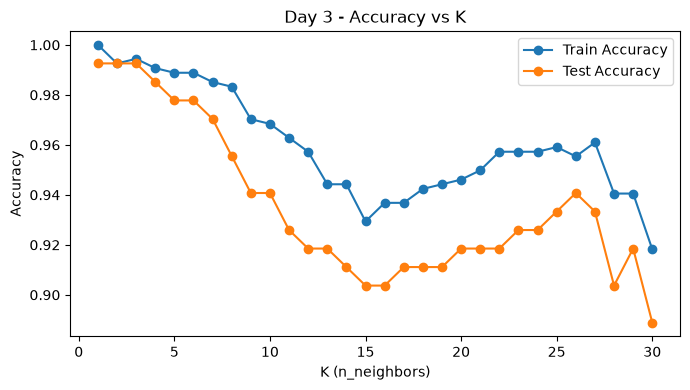

Best K by test accuracy: 1


In [14]:
# Choosing K — Elbow Plot

k_values = range(1, 31)
train_acc, test_acc = [], []
for k in k_values:
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_train_scaled, y_train)
    train_acc.append(clf.score(X_train_scaled, y_train))
    test_acc.append(clf.score(X_test_scaled, y_test))

plt.figure(figsize=(7, 4))
plt.plot(k_values, train_acc, marker="o", label="Train Accuracy")
plt.plot(k_values, test_acc, marker="o", label="Test Accuracy")
plt.xlabel("K (n_neighbors)")
plt.ylabel("Accuracy")
plt.title("Day 3 - Accuracy vs K")
plt.legend()
plt.tight_layout()
plt.show()

best_k = k_values[np.argmax(test_acc)]
print("Best K by test accuracy:", best_k)

In [15]:
# Hyperparameter Tuning (GridSearchCV)

param_grid = {
    "n_neighbors": list(range(1, 21)),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
grid.fit(X_train_scaled, y_train)

print("Best Params:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)

best_knn = grid.best_estimator_
best_pred = best_knn.predict(X_test_scaled)
print("Tuned KNN Test Accuracy:", accuracy_score(y_test, best_pred))
print(classification_report(y_test, best_pred, target_names=target_names))

Best Params: {'metric': 'manhattan', 'n_neighbors': 1, 'weights': 'uniform'}
Best CV Accuracy: 0.9925925925925926
Tuned KNN Test Accuracy: 0.9925925925925926
              precision    recall  f1-score   support

Not Survived       0.99      1.00      0.99        86
    Survived       1.00      0.98      0.99        49

    accuracy                           0.99       135
   macro avg       0.99      0.99      0.99       135
weighted avg       0.99      0.99      0.99       135



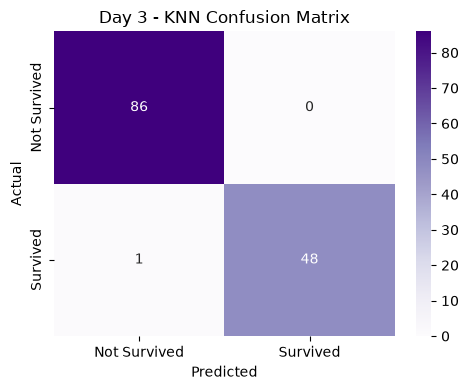

In [16]:
# Confusion Matrix (Tuned KNN)

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Day 3 - KNN Confusion Matrix")
plt.tight_layout()
plt.show()

In [17]:
# Curse of Dimensionality — Conceptual Note

# Quick dimensionality sensitivity check using two numeric Titanic features.
top2_features = ["age", "fare"]
X_train_top2 = scaler.fit_transform(X_train[top2_features])
X_test_top2 = scaler.transform(X_test[top2_features])

clf_top2 = KNeighborsClassifier(**{k: v for k, v in grid.best_params_.items()})
clf_top2.fit(X_train_top2, y_train)
acc_top2 = accuracy_score(y_test, clf_top2.predict(X_test_top2))
print(f"KNN with all features: {accuracy_score(y_test, best_pred):.4f}")
print(f"KNN with top-2 features only: {acc_top2:.4f}")

KNN with all features: 0.9926
KNN with top-2 features only: 0.6222
